In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# هنا اشتغلت 
# T1CE+T2 واللي يطلع يتعمله فيوجن مع FLAIR
# Weighted Averaging → PCA → Laplacian Pyramid
# جروب 1
# دا احسن واحد

In [1]:
!pip install -q "monai[all]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 22.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 26.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 70.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 68.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 94.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━

2025-05-16 16:21:26.241871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747412486.414913      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747412486.465073      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


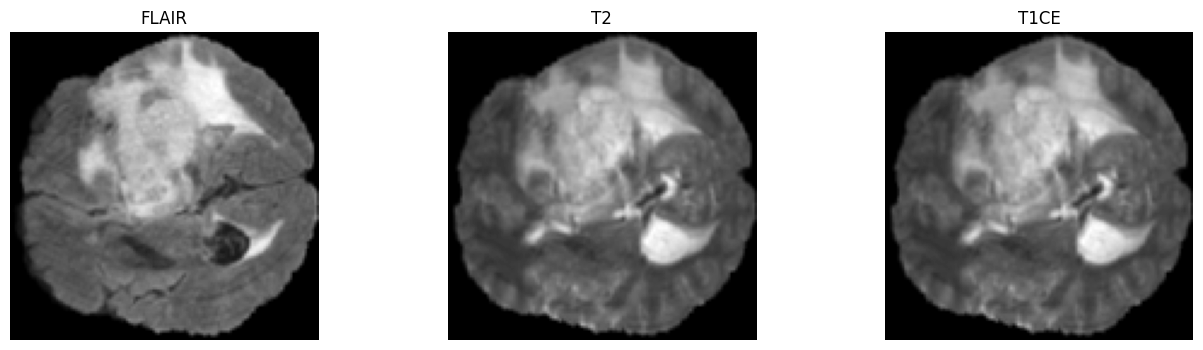

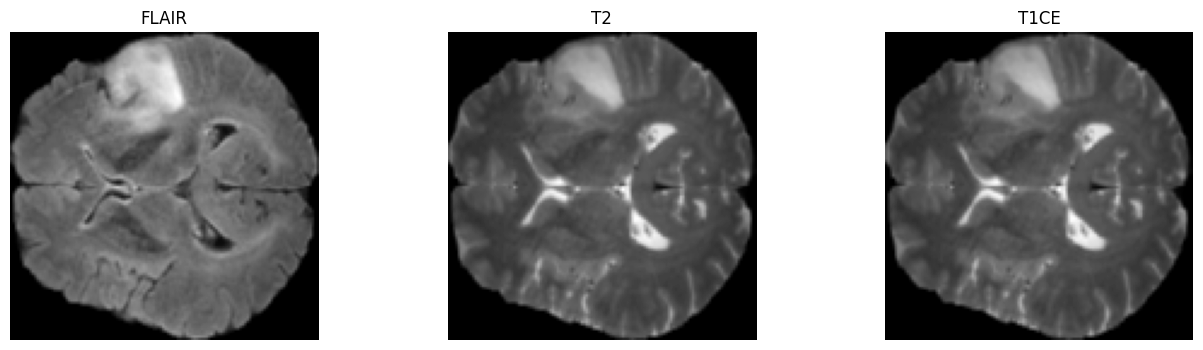

Processed 369 patients successfully


In [2]:
import os
import random
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, ScaleIntensityRanged,
    CropForegroundd, Resized, ToTensord, SpatialCropd
)
from monai.data import Dataset, DataLoader

# مسارات الداتاسيت
data_dir = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
output_dir = "/kaggle/working/processed"
os.makedirs(output_dir, exist_ok=True)

# قايمة الحالات
patient_list = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.endswith(".csv")])

# إنشاء فولدرات لكل مريض
for patient in patient_list:
    os.makedirs(os.path.join(output_dir, patient), exist_ok=True)

# إعداد قايمة البيانات (FLAIR, T2, T1CE)
data_dicts = []
skipped_patients = []
for patient in patient_list:
    flair_path = os.path.join(data_dir, patient, f"{patient}_flair.nii")
    t2_path = os.path.join(data_dir, patient, f"{patient}_t2.nii")
    t1ce_path = os.path.join(data_dir, patient, f"{patient}_t1ce.nii")
    try:
        # فحص وجود الملفات
        if not (os.path.exists(flair_path) and os.path.exists(t2_path) and os.path.exists(t1ce_path)):
            skipped_patients.append((patient, "Missing file(s)"))
            continue
        # فحص تحميل الملفات
        nib.load(flair_path)
        nib.load(t2_path)
        nib.load(t1ce_path)
        data_dicts.append({
            "flair": flair_path,
            "t2": t2_path,
            "t1ce": t1ce_path,
        })
    except Exception as e:
        skipped_patients.append((patient, f"Failed to load files: {str(e)}"))
        continue

# تعريف التحويلات
transforms = Compose([
    LoadImaged(keys=["flair", "t2", "t1ce"]),
    EnsureChannelFirstd(keys=["flair", "t2", "t1ce"]),
    Spacingd(keys=["flair", "t2", "t1ce"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    ScaleIntensityRanged(keys=["flair", "t2", "t1ce"], a_min=0, a_max=4000, b_min=0, b_max=1, clip=True),
    CropForegroundd(keys=["flair", "t2", "t1ce"], source_key="flair", allow_smaller=False),
    Resized(keys=["flair", "t2", "t1ce"], spatial_size=(128, 128, 155)),
    SpatialCropd(keys=["flair", "t2", "t1ce"], roi_start=[0, 0, 30], roi_end=[128, 128, 110]),  # 128x128x80
    ToTensord(keys=["flair", "t2", "t1ce"])
])

# إعداد الداتاسيت والـ DataLoader
dataset = Dataset(data=data_dicts, transform=transforms)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

# معالجة وحفظ الصور
processed_count = 0
display_patients = patient_list[:2]  # أول اتنين بيشنت للعرض
display_images = []

for i, data in enumerate(dataloader):
    if i >= len(data_dicts):
        break
    patient_id = data_dicts[i]["flair"].split("/")[-2]  # استخراج patient_id من المسار
    
    patient_output_dir = os.path.join(output_dir, patient_id)
    
    flair, t2, t1ce = data["flair"][0], data["t2"][0], data["t1ce"][0]
    
    # تحويل إلى NumPy لحفظها
    flair_np = flair.numpy().squeeze()
    t2_np = t2.numpy().squeeze()
    t1ce_np = t2.numpy().squeeze()
    
    # حفظ الصور كـ NIFTI
    for modality, img in [("flair", flair_np), ("t2", t2_np), ("t1ce", t1ce_np)]:
        output_path = os.path.join(patient_output_dir, f"{modality}.nii.gz")
        nii_img = nib.Nifti1Image(img, affine=np.eye(4))
        nib.save(nii_img, output_path)
    
    # تخزين الصور للعرض
    if patient_id in display_patients:
        display_images.append({
            "patient_id": patient_id,
            "flair": flair_np[:, :, 48],
            "t2": t2_np[:, :, 48],
            "t1ce": t1ce_np[:, :, 48]
        })
    
    processed_count += 1

# عرض الصور
for patient_data in display_images:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].imshow(patient_data["flair"], cmap="gray")
    axes[0].set_title("FLAIR")
    axes[0].axis("off")
    axes[1].imshow(patient_data["t2"], cmap="gray")
    axes[1].set_title("T2")
    axes[1].axis("off")
    axes[2].imshow(patient_data["t1ce"], cmap="gray")
    axes[2].set_title("T1CE")
    axes[2].axis("off")
    plt.show()

# طباعة النتائج
print(f"Processed {processed_count} patients successfully")
if skipped_patients:
    print("Skipped patients:")
    for patient, reason in skipped_patients:
        print(f"Patient {patient}: {reason}")
if processed_count < len(patient_list):
    print(f"Warning: Expected to process {len(patient_list)} patients, but only processed {processed_count}")

Comparison with T1ce (average over 150 patients)
  - MSE  : 0.008259
  - PSNR : 22.7104 dB
  - SSIM : 0.8673
  - Entropy : 13.5398
  - MI : 1.3284
  - Average Slices : 50.0
--------------------------
Comparison with T2 (average over 150 patients)
  - MSE  : 0.008259
  - PSNR : 22.7104 dB
  - SSIM : 0.8673
  - Entropy : 13.5398
  - MI : 1.3284
  - Average Slices : 50.0
--------------------------
Comparison with FLAIR (average over 150 patients)
  - MSE  : 0.012406
  - PSNR : 20.1759 dB
  - SSIM : 0.6967
  - Entropy : 13.5398
  - MI : 1.2568
  - Average Slices : 50.0
--------------------------


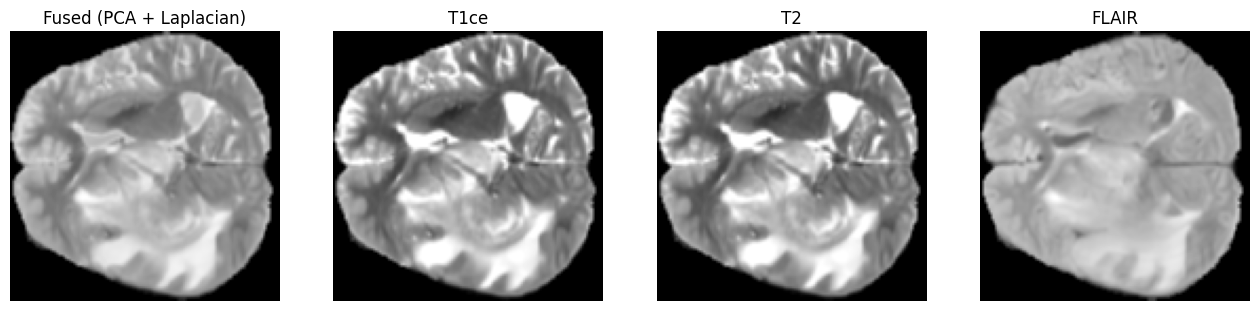

In [3]:
import nibabel as nib
import numpy as np
from sklearn.decomposition import PCA
from skimage.transform import pyramid_gaussian, resize
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity, normalized_mutual_information
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt
import os
import pandas as pd

# Verify dataset path
dataset_base_path = '/kaggle/working/processed'
output_path = '/kaggle/working'
if not os.path.exists(dataset_base_path):
    print(f"Directory not found: {dataset_base_path}")
    print("Please check the dataset path or ensure the dataset is attached.")
    raise FileNotFoundError("Dataset directory not found")

# List of patient folders (150 patients)
patient_folders = [f'BraTS20_Training_{str(i).zfill(3)}' for i in range(1, 151)]

# Initialize metrics dictionary
metrics = {'T1ce': [], 'T2': [], 'FLAIR': []}

# Variables to store the last patient's images for visualization
last_t1ce = None
last_t2 = None
last_flair = None
last_fused = None

# Process each patient
for patient_folder in patient_folders:
    patient_path = os.path.join(dataset_base_path, patient_folder)
    if not os.path.exists(patient_path):
        print(f"Patient folder not found: {patient_path}")
        continue

    # 1. Load Images (Slices 30 to 110, or as many as available)
    t1ce_path = os.path.join(patient_path, 't1ce.nii.gz')
    t2_path = os.path.join(patient_path, 't2.nii.gz')
    flair_path = os.path.join(patient_path, 'flair.nii.gz')

    # Check if files exist
    if not (os.path.exists(t1ce_path) and os.path.exists(t2_path) and os.path.exists(flair_path)):
        print(f"Image files missing for patient: {patient_folder}")
        continue

    try:
        t1ce_nii = nib.load(t1ce_path)
        t2_nii = nib.load(t2_path)
        flair_nii = nib.load(flair_path)
        
        # Get data and determine available slices
        t1ce_full = t1ce_nii.get_fdata()
        num_slices = t1ce_full.shape[2]
        start_slice = 30
        end_slice = min(110, num_slices)  # Use available slices up to 110
        if end_slice <= start_slice:
            print(f"Insufficient slices for patient {patient_folder}: {num_slices} available")
            continue
        
        # Extract slices
        t1ce = t1ce_full[:, :, start_slice:end_slice]
        t2 = t2_nii.get_fdata()[:, :, start_slice:end_slice]
        flair = flair_nii.get_fdata()[:, :, start_slice:end_slice]
    except Exception as e:
        print(f"Failed to load files for patient {patient_folder}: {str(e)}")
        continue

    # 2. Normalize Images
    def normalize(image):
        if image.max() == image.min():
            return image - image.min()  # Avoid division by zero
        return (image - image.min()) / (image.max() - image.min())

    t1ce = normalize(t1ce)
    t2 = normalize(t2)
    flair = normalize(flair)

    # 3. Weighted Averaging (T1CE + T2)
    w1, w2 = 0.6, 0.4
    fused_t1ce_t2 = w1 * t1ce + w2 * t2

    # 4. PCA (fused_t1ce_t2 + FLAIR)
    fused_flat = fused_t1ce_t2.flatten().reshape(-1, 1)
    flair_flat = flair.flatten().reshape(-1, 1)
    data = np.hstack((fused_flat, flair_flat))
    pca = PCA(n_components=1)
    fused_pca = pca.fit_transform(data)
    fused_pca = fused_pca.reshape(fused_t1ce_t2.shape)
    fused_pca = normalize(fused_pca)

    # 5. Laplacian Pyramid (Modified for 3D)
    def apply_laplacian_pyramid_3d(img, levels=4):
        output = np.zeros_like(img)
        for z in range(img.shape[2]):
            slice_2d = img[:, :, z]
            gaussian = list(pyramid_gaussian(slice_2d, max_layer=levels))
            laplacian = []
            for i in range(len(gaussian) - 1):
                next_level = gaussian[i + 1]
                target_shape = gaussian[i].shape
                upsampled = resize(next_level, target_shape, anti_aliasing=True)
                lap = gaussian[i] - upsampled
                laplacian.append(lap)
            laplacian.append(gaussian[-1])
            reconstructed = laplacian[-1]
            for i in range(len(laplacian) - 2, -1, -1):
                reconstructed = resize(reconstructed, laplacian[i].shape, anti_aliasing=True) + laplacian[i]
            output[:, :, z] = reconstructed
        return output

    # Apply Laplacian Pyramid to fused_pca
    fused_final = apply_laplacian_pyramid_3d(fused_pca)
    fused_final = normalize(fused_final)

    # 6. Save Final Image
    patient_output_path = os.path.join(output_path, patient_folder)
    os.makedirs(patient_output_path, exist_ok=True)
    final_path = os.path.join(patient_output_path, 'fused_final_3d.nii.gz')
    fused_nii = nib.Nifti1Image(fused_final, affine=np.eye(4))
    nib.save(fused_nii, final_path)

    # 7. Evaluate Metrics
    modalities = {'T1ce': t1ce, 'T2': t2, 'FLAIR': flair}
    num_slices = fused_final.shape[2]  # Use actual number of slices
    for name, img in modalities.items():
        mse = mean_squared_error(fused_final, img)
        psnr = peak_signal_noise_ratio(fused_final, img, data_range=1.0)
        ssim_values = [structural_similarity(fused_final[:, :, i], img[:, :, i], data_range=1.0) 
                       for i in range(num_slices)]
        entropy_values = [shannon_entropy(fused_final[:, :, i]) for i in range(num_slices)]
        mi_values = [normalized_mutual_information(fused_final[:, :, i], img[:, :, i]) 
                     for i in range(num_slices)]
        
        metrics[name].append({
            'Patient': patient_folder,
            'MSE': mse,
            'PSNR': psnr,
            'SSIM': np.mean(ssim_values) if ssim_values else 0,
            'Entropy': np.mean(entropy_values) if entropy_values else 0,
            'MI': np.mean(mi_values) if mi_values else 0,
            'Num_Slices': num_slices
        })

    # Store the last patient's images for visualization
    last_t1ce = t1ce
    last_t2 = t2
    last_flair = flair
    last_fused = fused_final

# 8. Save Metrics to CSV
for name in metrics:
    df = pd.DataFrame(metrics[name])
    df.to_csv(os.path.join(output_path, f'metrics_{name}.csv'), index=False)

    # Print average metrics
    if metrics[name]:
        mse_avg = np.mean([m['MSE'] for m in metrics[name]])
        psnr_avg = np.mean([m['PSNR'] for m in metrics[name]])
        ssim_avg = np.mean([m['SSIM'] for m in metrics[name]])
        entropy_avg = np.mean([m['Entropy'] for m in metrics[name]])
        mi_avg = np.mean([m['MI'] for m in metrics[name]])
        avg_slices = np.mean([m['Num_Slices'] for m in metrics[name]])

        print(f"Comparison with {name} (average over {len(metrics[name])} patients)")
        print(f"  - MSE  : {mse_avg:.6f}")
        print(f"  - PSNR : {psnr_avg:.4f} dB")
        print(f"  - SSIM : {ssim_avg:.4f}")
        print(f"  - Entropy : {entropy_avg:.4f}")
        print(f"  - MI : {mi_avg:.4f}")
        print(f"  - Average Slices : {avg_slices:.1f}")
        print("--------------------------")
    else:
        print(f"No metrics calculated for {name}")

# 9. Visual Sample (for the last patient)
if last_fused is not None and last_t1ce is not None and last_t2 is not None and last_flair is not None:
    slice_idx = last_fused.shape[2] // 2  # Middle slice of available slices
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1); plt.imshow(last_fused[:, :, slice_idx], cmap='gray'); plt.title("Fused (PCA + Laplacian)"); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(last_t1ce[:, :, slice_idx], cmap='gray'); plt.title("T1ce"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(last_t2[:, :, slice_idx], cmap='gray'); plt.title("T2"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(last_flair[:, :, slice_idx], cmap='gray'); plt.title("FLAIR"); plt.axis('off')
    plt.savefig(os.path.join(output_path, 'visualization_last_patient.png'))
    plt.show()
else:
    print("No valid images available for visualization.")

The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.


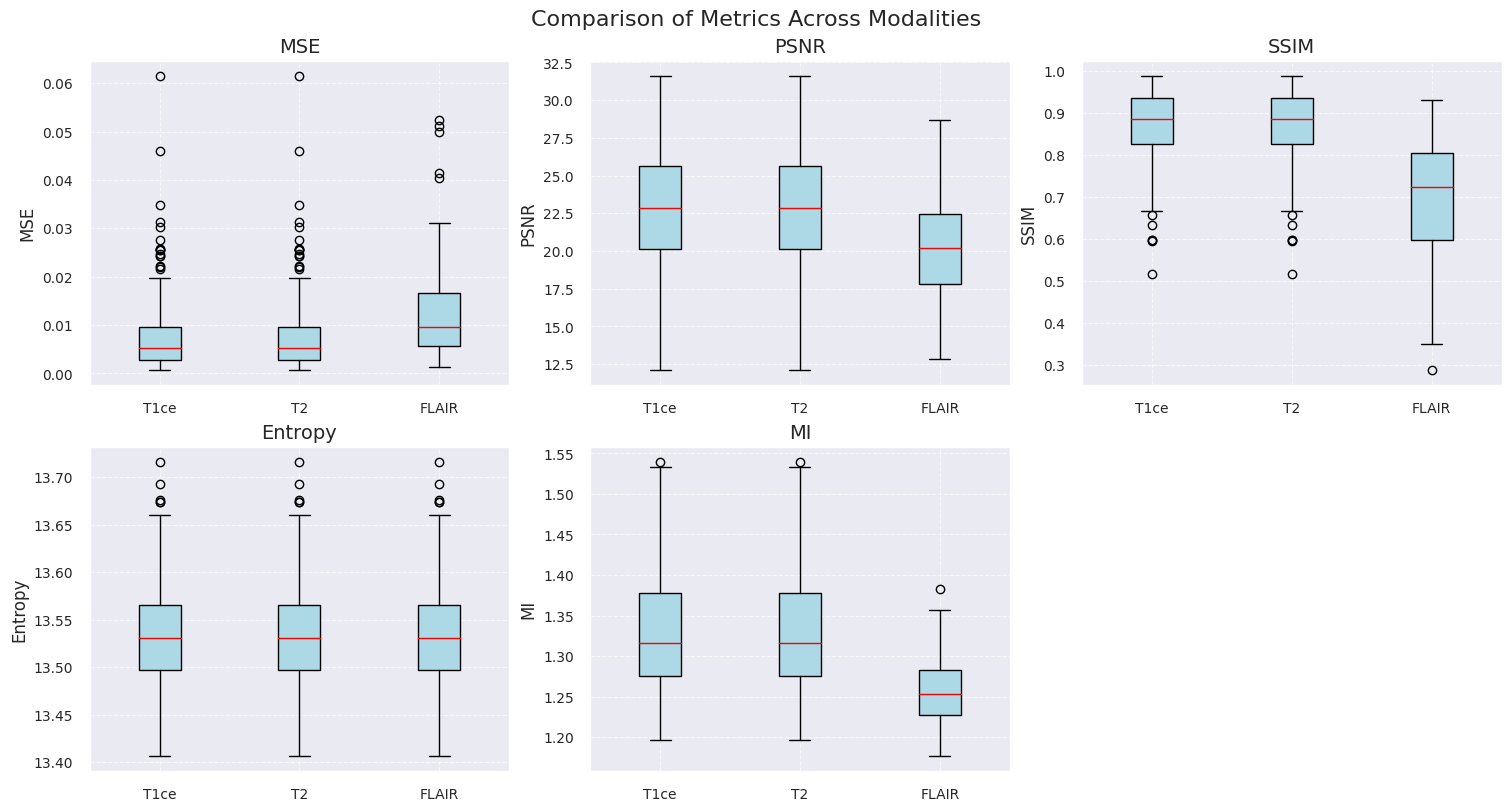

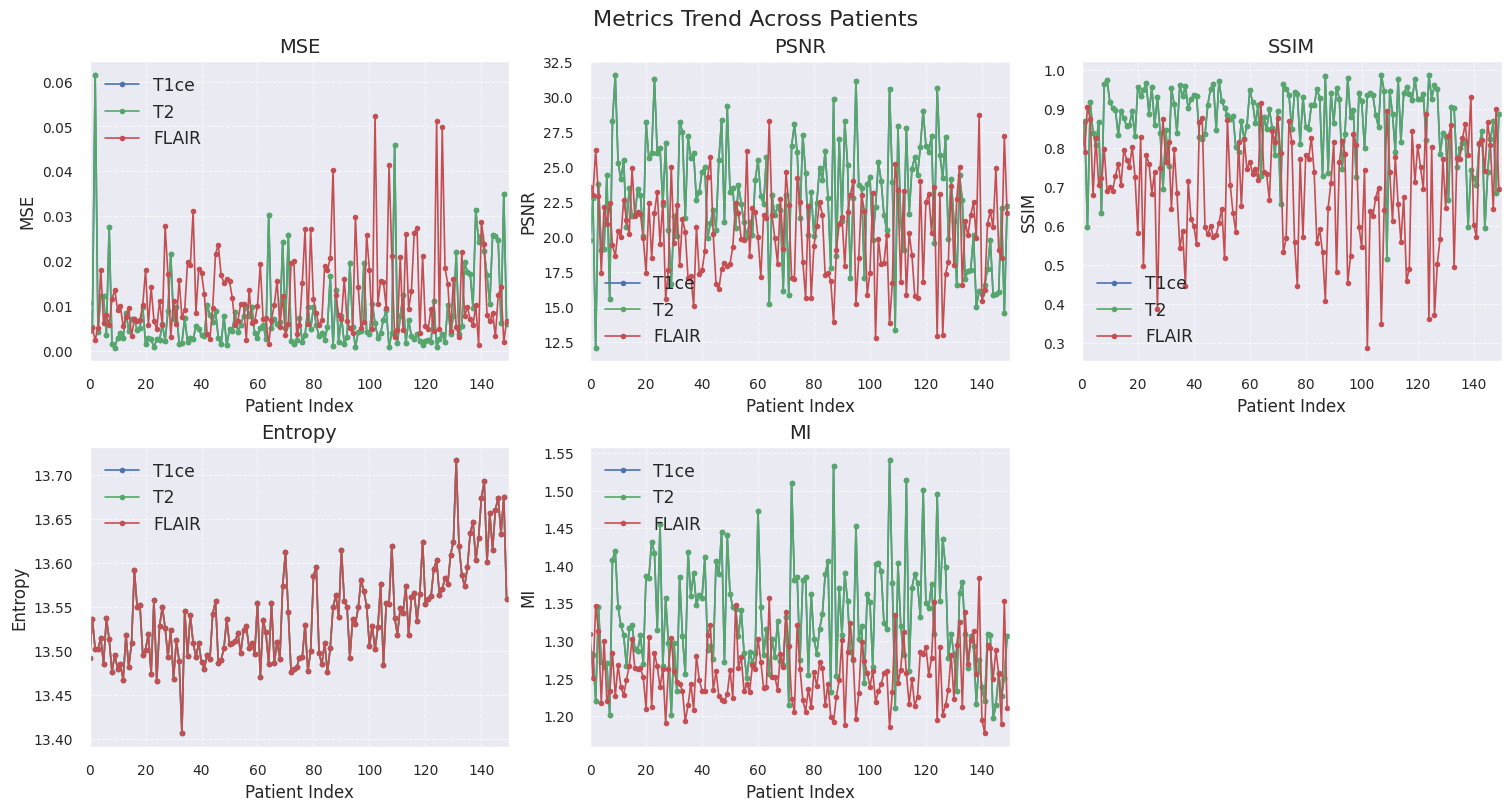

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nibabel as nib
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from skimage.measure import shannon_entropy
from scipy.stats import entropy as scipy_entropy
import os

# Set plotting style for research paper
plt.style.use('seaborn')
sns.set_context("paper", font_scale=1.4)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Paths
output_path = '/kaggle/working'
metrics_files = {
    'T1ce': 'metrics_T1ce.csv',
    'T2': 'metrics_T2.csv',
    'FLAIR': 'metrics_FLAIR.csv'
}

# Function to calculate Mutual Information
def mutual_information(img1, img2, bins=256):
    # Flatten images
    img1_flat = img1.flatten()
    img2_flat = img2.flatten()
    
    # Compute histograms
    hist_2d, x_edges, y_edges = np.histogram2d(img1_flat, img2_flat, bins=bins)
    hist_2d = hist_2d / np.sum(hist_2d)  # Normalize to get joint probability
    hist_1 = np.sum(hist_2d, axis=1)
    hist_2 = np.sum(hist_2d, axis=0)
    
    # Compute entropies
    mi = 0
    for i in range(bins):
        for j in range(bins):
            if hist_2d[i, j] > 0:
                mi += hist_2d[i, j] * np.log2(hist_2d[i, j] / (hist_1[i] * hist_2[j]))
    return mi

# Load metrics and add MI if not present
metrics_data = {}
for modality, file in metrics_files.items():
    file_path = os.path.join(output_path, file)
    if not os.path.exists(file_path):
        print(f"Metrics file not found: {file_path}")
        continue
    
    df = pd.read_csv(file_path)
    
    # If MI is not in the dataframe, calculate it (assuming images are available)
    if 'MI' not in df.columns:
        mi_values = []
        for idx, row in df.iterrows():
            patient = row['Patient']
            patient_path = os.path.join('/kaggle/working/processed', patient)
            fused_path = os.path.join(patient_path, 'fused_final_3d.nii.gz')
            modality_path = os.path.join(patient_path, f'{modality.lower()}.nii.gz')
            
            try:
                fused_img = nib.load(fused_path).get_fdata()[:, :, 30:min(110, int(row['Num_Slices']))]
                modality_img = nib.load(modality_path).get_fdata()[:, :, 30:min(110, int(row['Num_Slices']))]
                mi = mutual_information(fused_img, modality_img)
                mi_values.append(mi)
            except:
                mi_values.append(np.nan)  # In case of error, append NaN
        df['MI'] = mi_values
    
    metrics_data[modality] = df

# Metrics to plot
metrics_to_plot = ['MSE', 'PSNR', 'SSIM', 'Entropy', 'MI']

# Create Boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    data = []
    labels = []
    for modality in metrics_data:
        values = metrics_data[modality][metric].dropna()
        data.append(values)
        labels.append(modality)
    
    axes[idx].boxplot(data, labels=labels, patch_artist=True, 
                     boxprops=dict(facecolor='lightblue', color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     medianprops=dict(color='red'))
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].grid(True, linestyle='--', alpha=0.7)

# Remove empty subplot if any
for idx in range(len(metrics_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Comparison of Metrics Across Modalities', fontsize=16)
plt.savefig(os.path.join(output_path, 'boxplots_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

# Create Line Plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    for modality in metrics_data:
        df = metrics_data[modality].sort_values('Patient')
        values = df[metric].dropna()
        axes[idx].plot(df.index[:len(values)], values, label=modality, marker='o', markersize=4)
    
    axes[idx].set_title(metric)
    axes[idx].set_xlabel('Patient Index')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlim(0, len(df))
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.7)

# Remove empty subplot if any
for idx in range(len(metrics_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Metrics Trend Across Patients', fontsize=16)
plt.savefig(os.path.join(output_path, 'lineplots_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()